# 01b - PVGIS Preprocessing

Preprocesamiento del dataset público PVGIS-ERA5 para el benchmark de metaheurísticas.

**Dataset:** PVGIS-ERA5, Querétaro, México (lat=20.563425, lon=-100.36943889)
**Periodo:** 2019–2022 (4 años, resolución horaria)
**Target:** GHI — Irradiancia Horizontal Global (W/m²)
**Features:** TempAir, WindSpeed, hour, dayofyear, month

Salidas generadas:
- `outputs/pvgis/arrays/` — arrays NumPy (train/val/test)
- `outputs/pvgis/scalers/` — scalers MinMax
- `outputs/pvgis/figures/` — visualizaciones
- `outputs/pvgis/preprocessing_config.json`
- `outputs/pvgis/preprocessing_summary.json`

In [5]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [6]:
BASE_DIR = "/home/jovyan/work"
DATA_DIR   = os.path.join(BASE_DIR, "data")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs", "pvgis")
SCALER_DIR = os.path.join(OUTPUT_DIR, "scalers")
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
ARRAYS_DIR = os.path.join(OUTPUT_DIR, "arrays")

for d in [OUTPUT_DIR, SCALER_DIR, FIGURES_DIR, ARRAYS_DIR]:
    os.makedirs(d, exist_ok=True)

print("OUTPUT_DIR:", OUTPUT_DIR)

OUTPUT_DIR: /home/jovyan/work/outputs/pvgis


In [7]:
CONFIG = {
    "file_name":            "pvgis_raw.csv",
    "source":               "PVGIS-ERA5",
    "latitude":             20.563425,
    "longitude":            -100.36943889,
    "timezone_offset_h":    -6,          # UTC-6 (Querétaro, hora central)
    "target":               "GHI",
    "window_size":          24,           # 24 horas de contexto
    "horizon":              1,            # predecir 1 hora adelante
    "train_ratio":          0.70,
    "val_ratio":            0.15,
    "test_ratio":           0.15,
    "irradiance_threshold": 50,           # W/m² umbral diurno
    "features": [
        "TempAir",
        "WindSpeed",
        "hour",
        "dayofyear",
        "month"
    ]
}

## 1. Carga de datos

In [8]:
file_path = os.path.join(DATA_DIR, CONFIG["file_name"])

df = pd.read_csv(file_path, index_col="TIMESTAMP", parse_dates=True)

print("Shape:", df.shape)
print("Columnas:", list(df.columns))
df.head()

Shape: (35064, 9)
Columnas: ['GHI', 'poa_direct', 'poa_sky_diffuse', 'solar_elevation', 'TempAir', 'WindSpeed', 'hour', 'dayofyear', 'month']


,GHI,poa_direct,poa_sky_diffuse,solar_elevation,TempAir,WindSpeed,hour,dayofyear,month
TIMESTAMP,,,,,,,,,
2019-01-01 00:30:00+00:00,0.0,0.0,0.0,-4.67,19.10,1.86,0,1,1
2019-01-01 01:30:00+00:00,0.0,0.0,0.0,0.00,17.23,1.93,1,1,1
2019-01-01 02:30:00+00:00,0.0,0.0,0.0,0.00,15.84,1.72,2,1,1
2019-01-01 03:30:00+00:00,0.0,0.0,0.0,0.00,14.30,1.24,3,1,1
2019-01-01 04:30:00+00:00,0.0,0.0,0.0,0.00,13.01,1.45,4,1,1


In [9]:
# Convertir de UTC a hora local (UTC-6)
df.index = df.index.tz_convert("America/Mexico_City").tz_localize(None)
df.index.name = "TIMESTAMP"

print("Periodo (hora local):")
print(" Inicio:", df.index.min())
print(" Fin   :", df.index.max())
print(" Filas :", len(df))

Periodo (hora local):
 Inicio: 2018-12-31 18:30:00
 Fin   : 2022-12-31 17:30:00
 Filas : 35064


## 2. Exploración y estadísticas básicas

In [10]:
df[["GHI", "TempAir", "WindSpeed"]].describe()

,GHI,TempAir,WindSpeed
count,35064.000000,35064.000000,35064.000000
mean,251.251427,17.297210,2.215190
std,333.952600,5.541351,1.243591
min,0.000000,1.940000,0.000000
25%,0.000000,13.480000,1.240000
50%,9.000000,16.560000,1.930000
75%,511.470000,21.422500,3.030000
max,1118.850000,32.790000,9.310000


In [11]:
print("Valores nulos:")
print(df.isnull().sum())

Valores nulos:
GHI                0
poa_direct         0
poa_sky_diffuse    0
solar_elevation    0
TempAir            0
WindSpeed          0
hour               0
dayofyear          0
month              0
dtype: int64


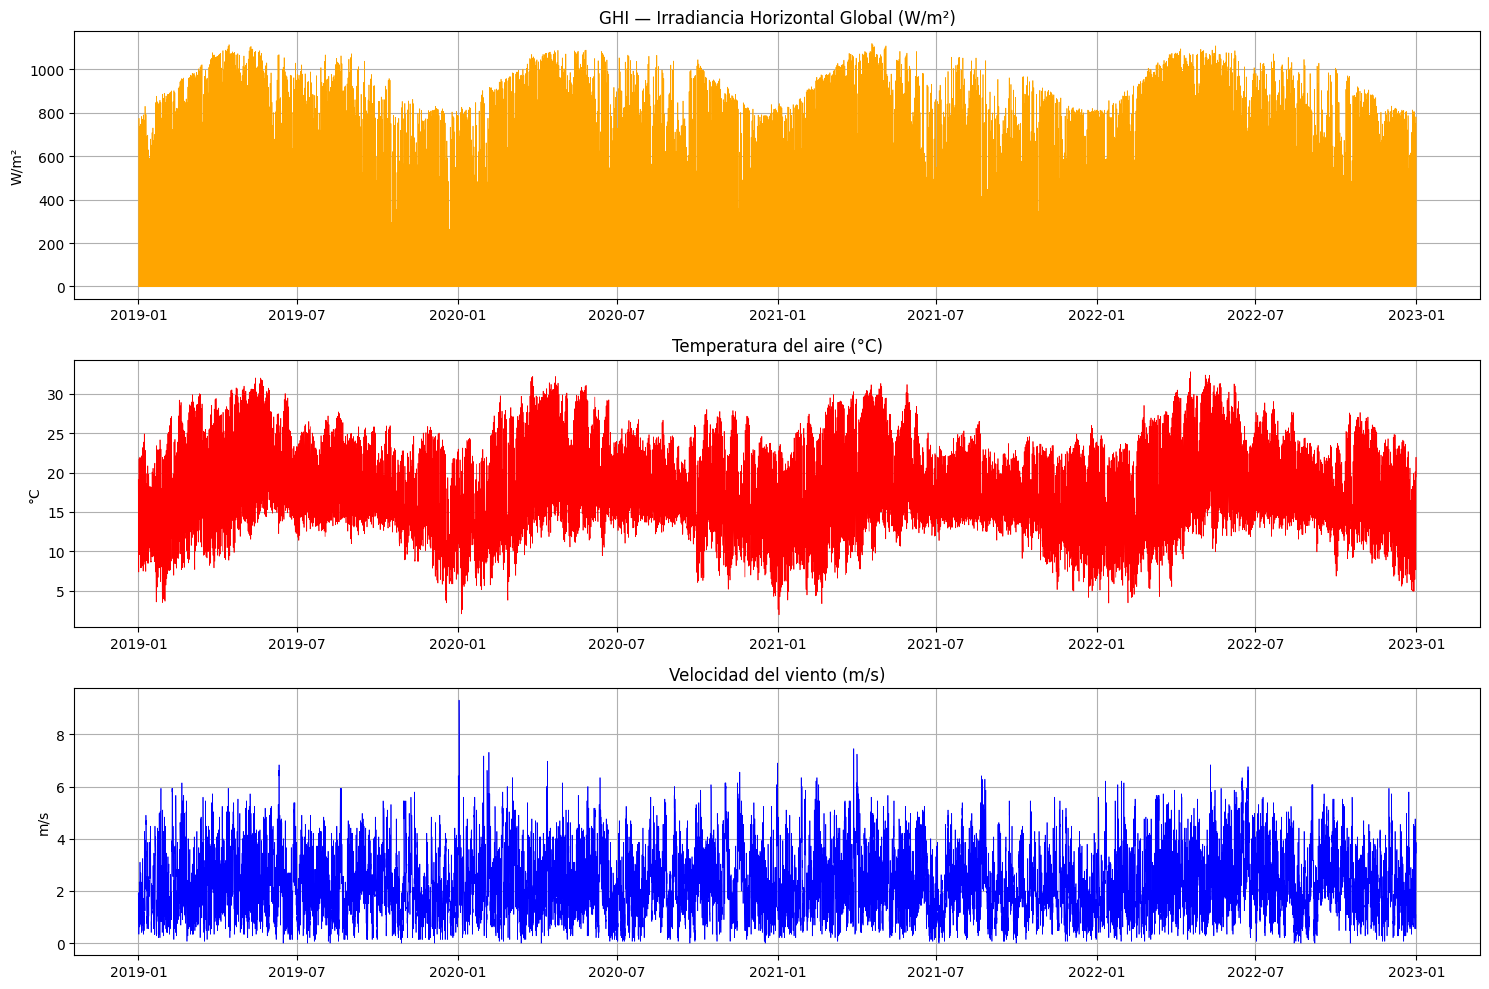

Guardado: /home/jovyan/work/outputs/pvgis/figures/pvgis_series_raw.png


In [12]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

axes[0].plot(df.index, df["GHI"], linewidth=0.5, color="orange")
axes[0].set_title("GHI — Irradiancia Horizontal Global (W/m²)")
axes[0].set_ylabel("W/m²")
axes[0].grid(True)

axes[1].plot(df.index, df["TempAir"], linewidth=0.5, color="red")
axes[1].set_title("Temperatura del aire (°C)")
axes[1].set_ylabel("°C")
axes[1].grid(True)

axes[2].plot(df.index, df["WindSpeed"], linewidth=0.5, color="blue")
axes[2].set_title("Velocidad del viento (m/s)")
axes[2].set_ylabel("m/s")
axes[2].grid(True)

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, "pvgis_series_raw.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("Guardado:", fig_path)

## 3. Limpieza de datos

In [13]:
original_shape = df.shape

# Filtros físicos
df = df[df["GHI"] >= 0]                            # radiación no negativa
df = df[(df["TempAir"] > -20) & (df["TempAir"] < 60)]  # temperatura válida
df = df[(df["WindSpeed"] >= 0) & (df["WindSpeed"] < 50)]  # viento válido

# Eliminar duplicados en el índice
df = df[~df.index.duplicated(keep="first")]

print(f"Shape original : {original_shape}")
print(f"Shape limpiado : {df.shape}")
print(f"Filas eliminadas: {original_shape[0] - df.shape[0]}")

Shape original : (35064, 9)
Shape limpiado : (35060, 9)
Filas eliminadas: 4


In [14]:
# Verificar frecuencia horaria y detectar huecos
freq = pd.infer_freq(df.index)
print("Frecuencia inferida:", freq)

expected_idx = pd.date_range(df.index.min(), df.index.max(), freq="1h")
missing_ts = expected_idx.difference(df.index)
print(f"Timestamps faltantes: {len(missing_ts)}")

if len(missing_ts) > 0:
    df = df.reindex(expected_idx)
    df = df.interpolate(method="time", limit=3)   # interpolar huecos cortos
    df = df.dropna()                               # eliminar huecos largos
    print(f"Shape tras interpolación: {df.shape}")

Frecuencia inferida: None
Timestamps faltantes: 4
Shape tras interpolación: (35064, 9)


## 4. Ingeniería de variables

In [15]:
# Recalcular variables temporales con hora local correcta
df["hour"]      = df.index.hour
df["dayofyear"] = df.index.dayofyear
df["month"]     = df.index.month

# Máscara diurna
df["is_daylight"] = df["GHI"] > CONFIG["irradiance_threshold"]

print("Distribución diurna/nocturna:")
print(df["is_daylight"].value_counts())
print(df["is_daylight"].value_counts(normalize=True).round(3))

Distribución diurna/nocturna:
is_daylight
False    18987
True     16077
Name: count, dtype: int64
is_daylight
False    0.541
True     0.459
Name: proportion, dtype: float64


In [16]:
features = CONFIG["features"]
target   = CONFIG["target"]

print("Features:", features)
print("Target  :", target)

df[features + [target]].describe()

Features: ['TempAir', 'WindSpeed', 'hour', 'dayofyear', 'month']
Target  : GHI


,TempAir,WindSpeed,hour,dayofyear,month,GHI
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000
mean,17.297353,2.215254,11.500000,183.125257,6.522930,251.251427
std,5.541277,1.243548,6.922285,105.440146,3.448752,333.952600
min,1.940000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,13.480000,1.240000,5.750000,92.000000,4.000000,0.000000
50%,16.560000,1.930000,11.500000,183.000000,7.000000,9.000000
75%,21.422500,3.030000,17.250000,274.000000,10.000000,511.470000
max,32.790000,9.310000,23.000000,366.000000,12.000000,1118.850000


## 5. Normalización (MinMaxScaler)

In [17]:
# Split temporal ANTES de ajustar los scalers (evita data leakage)
n_samples  = len(df)
train_end  = int(n_samples * CONFIG["train_ratio"])
val_end    = train_end + int(n_samples * CONFIG["val_ratio"])

df_train = df.iloc[:train_end]
df_val   = df.iloc[train_end:val_end]
df_test  = df.iloc[val_end:]

print(f"Train : {df_train.index[0]}  →  {df_train.index[-1]}  ({len(df_train):,} filas)")
print(f"Val   : {df_val.index[0]}  →  {df_val.index[-1]}  ({len(df_val):,} filas)")
print(f"Test  : {df_test.index[0]}  →  {df_test.index[-1]}  ({len(df_test):,} filas)")

Train : 2018-12-31 18:30:00  →  2021-10-19 09:30:00  (24,544 filas)
Val   : 2021-10-19 10:30:00  →  2022-05-26 12:30:00  (5,259 filas)
Test  : 2022-05-26 13:30:00  →  2022-12-31 17:30:00  (5,261 filas)


In [18]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit solo sobre train
X_train_raw = scaler_X.fit_transform(df_train[features])
y_train_raw = scaler_y.fit_transform(df_train[[target]])

# Transform val y test con el mismo scaler
X_val_raw  = scaler_X.transform(df_val[features])
y_val_raw  = scaler_y.transform(df_val[[target]])

X_test_raw = scaler_X.transform(df_test[features])
y_test_raw = scaler_y.transform(df_test[[target]])

# Guardar scalers
joblib.dump(scaler_X, os.path.join(SCALER_DIR, "scaler_X.pkl"))
joblib.dump(scaler_y, os.path.join(SCALER_DIR, "scaler_y.pkl"))

print("Scalers guardados en:", SCALER_DIR)
print(f"X_train_raw: {X_train_raw.shape}")
print(f"X_val_raw  : {X_val_raw.shape}")
print(f"X_test_raw : {X_test_raw.shape}")

Scalers guardados en: /home/jovyan/work/outputs/pvgis/scalers
X_train_raw: (24544, 5)
X_val_raw  : (5259, 5)
X_test_raw : (5261, 5)


## 6. Creación de secuencias (ventana deslizante)

In [19]:
def create_sequences(X, y, timestamps, daylight_flags, window_size, horizon):
    """Genera secuencias de ventana deslizante para series temporales."""
    X_seq, y_seq, ts_seq, dl_seq = [], [], [], []

    for i in range(window_size, len(X) - horizon + 1):
        X_seq.append(X[i - window_size:i])
        y_seq.append(y[i + horizon - 1])
        ts_seq.append(timestamps[i + horizon - 1])
        dl_seq.append(daylight_flags[i + horizon - 1])

    return (
        np.array(X_seq),
        np.array(y_seq),
        np.array(ts_seq),
        np.array(dl_seq)
    )

In [20]:
W = CONFIG["window_size"]
H = CONFIG["horizon"]

X_train, y_train, ts_train, dl_train = create_sequences(
    X_train_raw, y_train_raw,
    df_train.index.to_numpy(),
    df_train["is_daylight"].to_numpy(),
    W, H
)

X_val, y_val, ts_val, dl_val = create_sequences(
    X_val_raw, y_val_raw,
    df_val.index.to_numpy(),
    df_val["is_daylight"].to_numpy(),
    W, H
)

X_test, y_test, ts_test, dl_test = create_sequences(
    X_test_raw, y_test_raw,
    df_test.index.to_numpy(),
    df_test["is_daylight"].to_numpy(),
    W, H
)

print(f"Train : X={X_train.shape}  y={y_train.shape}")
print(f"Val   : X={X_val.shape}  y={y_val.shape}")
print(f"Test  : X={X_test.shape}  y={y_test.shape}")

Train : X=(24520, 24, 5)  y=(24520, 1)
Val   : X=(5235, 24, 5)  y=(5235, 1)
Test  : X=(5237, 24, 5)  y=(5237, 1)


In [21]:
print("Periodos de secuencias:")
print(f"  Train : {ts_train[0]}  →  {ts_train[-1]}")
print(f"  Val   : {ts_val[0]}  →  {ts_val[-1]}")
print(f"  Test  : {ts_test[0]}  →  {ts_test[-1]}")

Periodos de secuencias:
  Train : 2019-01-01T18:30:00.000000000  →  2021-10-19T09:30:00.000000000
  Val   : 2021-10-20T10:30:00.000000000  →  2022-05-26T12:30:00.000000000
  Test  : 2022-05-27T13:30:00.000000000  →  2022-12-31T17:30:00.000000000


## 7. Guardar arrays

In [22]:
arrays = {
    "X_train": X_train, "y_train": y_train,
    "X_val":   X_val,   "y_val":   y_val,
    "X_test":  X_test,  "y_test":  y_test,
    "timestamps_train": ts_train,
    "timestamps_val":   ts_val,
    "timestamps_test":  ts_test,
    "daylight_train":   dl_train,
    "daylight_val":     dl_val,
    "daylight_test":    dl_test,
}

for name, arr in arrays.items():
    path = os.path.join(ARRAYS_DIR, f"{name}.npy")
    np.save(path, arr)
    print(f"  {name}.npy  →  {arr.shape}")

print("\nTodos los arrays guardados en:", ARRAYS_DIR)

  X_train.npy  →  (24520, 24, 5)
  y_train.npy  →  (24520, 1)
  X_val.npy  →  (5235, 24, 5)
  y_val.npy  →  (5235, 1)
  X_test.npy  →  (5237, 24, 5)
  y_test.npy  →  (5237, 1)
  timestamps_train.npy  →  (24520,)
  timestamps_val.npy  →  (5235,)
  timestamps_test.npy  →  (5237,)
  daylight_train.npy  →  (24520,)
  daylight_val.npy  →  (5235,)
  daylight_test.npy  →  (5237,)

Todos los arrays guardados en: /home/jovyan/work/outputs/pvgis/arrays


## 8. Visualización del dataset limpio

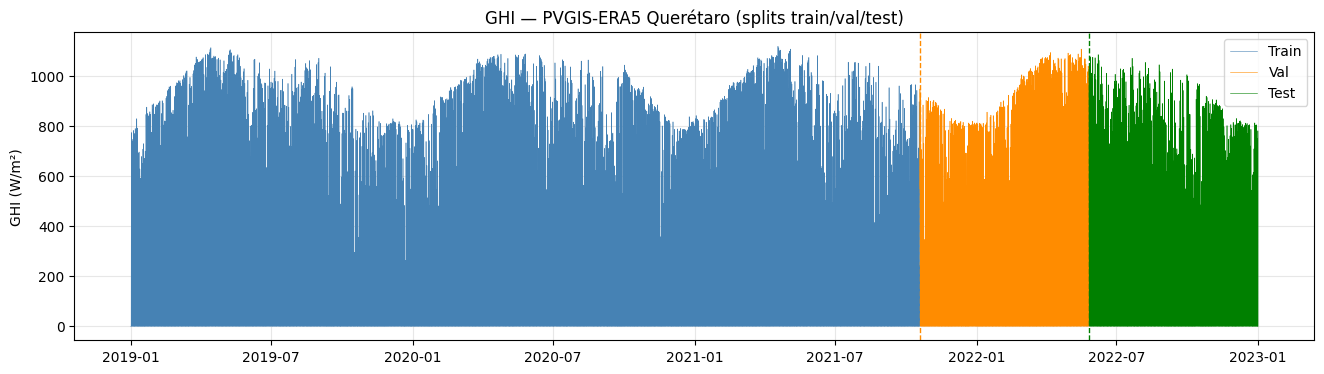

Guardado: /home/jovyan/work/outputs/pvgis/figures/pvgis_ghi_splits.png


In [23]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(df_train.index, df_train["GHI"], linewidth=0.4, color="steelblue",  label="Train")
ax.plot(df_val.index,   df_val["GHI"],   linewidth=0.4, color="darkorange", label="Val")
ax.plot(df_test.index,  df_test["GHI"],  linewidth=0.4, color="green",      label="Test")

ax.axvline(df_val.index[0],  color="darkorange", linestyle="--", linewidth=1)
ax.axvline(df_test.index[0], color="green",      linestyle="--", linewidth=1)

ax.set_title("GHI — PVGIS-ERA5 Querétaro (splits train/val/test)")
ax.set_ylabel("GHI (W/m²)")
ax.legend()
ax.grid(True, alpha=0.3)

fig_path = os.path.join(FIGURES_DIR, "pvgis_ghi_splits.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("Guardado:", fig_path)

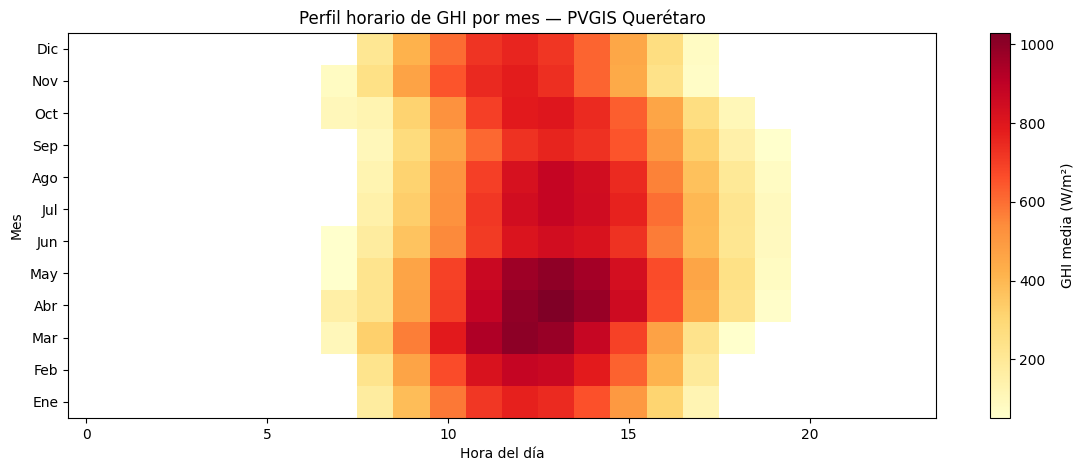

Guardado: /home/jovyan/work/outputs/pvgis/figures/pvgis_heatmap_ghi.png


In [24]:
# Perfil horario promedio por mes
df["GHI_daylight"] = df["GHI"].where(df["is_daylight"])
pivot = df.groupby(["month", "hour"])["GHI_daylight"].mean().unstack("hour")

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(pivot, aspect="auto", cmap="YlOrRd", origin="lower")
plt.colorbar(im, ax=ax, label="GHI media (W/m²)")
ax.set_xlabel("Hora del día")
ax.set_ylabel("Mes")
ax.set_title("Perfil horario de GHI por mes — PVGIS Querétaro")
ax.set_yticks(range(12))
ax.set_yticklabels(["Ene","Feb","Mar","Abr","May","Jun",
                    "Jul","Ago","Sep","Oct","Nov","Dic"])

fig_path = os.path.join(FIGURES_DIR, "pvgis_heatmap_ghi.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("Guardado:", fig_path)

## 9. Guardar configuración y resumen

In [25]:
CONFIG["n_features"]  = len(features)
CONFIG["n_samples"]   = int(len(X_train) + len(X_val) + len(X_test))
CONFIG["train_size"]  = int(len(X_train))
CONFIG["val_size"]    = int(len(X_val))
CONFIG["test_size"]   = int(len(X_test))

config_path = os.path.join(OUTPUT_DIR, "preprocessing_config.json")
with open(config_path, "w") as f:
    json.dump(CONFIG, f, indent=4)
print("Config guardada:", config_path)

Config guardada: /home/jovyan/work/outputs/pvgis/preprocessing_config.json


In [26]:
summary = {
    "total_rows_raw":     int(original_shape[0]),
    "total_rows_clean":   int(df.shape[0]),
    "removed_rows":       int(original_shape[0] - df.shape[0]),
    "total_sequences":    int(CONFIG["n_samples"]),
    "train_sequences":    int(CONFIG["train_size"]),
    "val_sequences":      int(CONFIG["val_size"]),
    "test_sequences":     int(CONFIG["test_size"]),
    "window_size":        CONFIG["window_size"],
    "horizon":            CONFIG["horizon"],
    "n_features":         CONFIG["n_features"],
    "target":             CONFIG["target"],
    "train_start":        str(ts_train[0]),
    "train_end":          str(ts_train[-1]),
    "val_start":          str(ts_val[0]),
    "val_end":            str(ts_val[-1]),
    "test_start":         str(ts_test[0]),
    "test_end":           str(ts_test[-1]),
    "daylight_pct_train": float(dl_train.mean().round(4)),
    "daylight_pct_val":   float(dl_val.mean().round(4)),
    "daylight_pct_test":  float(dl_test.mean().round(4)),
    "ghi_mean_daylight":  float(df.loc[df["is_daylight"], "GHI"].mean().round(2)),
    "ghi_max":            float(df["GHI"].max()),
}

summary_path = os.path.join(OUTPUT_DIR, "preprocessing_summary.json")
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=4)

print("Resumen guardado:", summary_path)
summary

Resumen guardado: /home/jovyan/work/outputs/pvgis/preprocessing_summary.json


{'total_rows_raw': 35064,
 'total_rows_clean': 35064,
 'removed_rows': 0,
 'total_sequences': 34992,
 'train_sequences': 24520,
 'val_sequences': 5235,
 'test_sequences': 5237,
 'window_size': 24,
 'horizon': 1,
 'n_features': 5,
 'target': 'GHI',
 'train_start': '2019-01-01T18:30:00.000000000',
 'train_end': '2021-10-19T09:30:00.000000000',
 'val_start': '2021-10-20T10:30:00.000000000',
 'val_end': '2022-05-26T12:30:00.000000000',
 'test_start': '2022-05-27T13:30:00.000000000',
 'test_end': '2022-12-31T17:30:00.000000000',
 'daylight_pct_train': 0.4593,
 'daylight_pct_val': 0.4481,
 'daylight_pct_test': 0.465,
 'ghi_mean_daylight': 545.69,
 'ghi_max': 1118.85}

## 10. Verificación final

In [27]:
print("=" * 55)
print("RESUMEN DEL PREPROCESAMIENTO PVGIS")
print("=" * 55)
print(f"Dataset     : PVGIS-ERA5, Querétaro MX")
print(f"Resolución  : Horaria")
print(f"Features    : {features}  (n={len(features)})")
print(f"Target      : {target}")
print(f"Window      : {W} h  |  Horizon: {H} h")
print()
fmt = lambda ts: str(ts)[:10]
print(f"Train  {X_train.shape}  {fmt(ts_train[0])} → {fmt(ts_train[-1])}")
print(f"Val    {X_val.shape}  {fmt(ts_val[0])} → {fmt(ts_val[-1])}")
print(f"Test   {X_test.shape}  {fmt(ts_test[0])} → {fmt(ts_test[-1])}")
print()
print(f"Scalers: {SCALER_DIR}")
print(f"Arrays : {ARRAYS_DIR}")
print("=" * 55)
print("✓ Preprocesamiento completo. Continuar con 02_models_pvgis.ipynb")

RESUMEN DEL PREPROCESAMIENTO PVGIS
Dataset     : PVGIS-ERA5, Querétaro MX
Resolución  : Horaria
Features    : ['TempAir', 'WindSpeed', 'hour', 'dayofyear', 'month']  (n=5)
Target      : GHI
Window      : 24 h  |  Horizon: 1 h

Train  (24520, 24, 5)  2019-01-01 → 2021-10-19
Val    (5235, 24, 5)  2021-10-20 → 2022-05-26
Test   (5237, 24, 5)  2022-05-27 → 2022-12-31

Scalers: /home/jovyan/work/outputs/pvgis/scalers
Arrays : /home/jovyan/work/outputs/pvgis/arrays
✓ Preprocesamiento completo. Continuar con 02_models_pvgis.ipynb
